# Make plots

I have copied the MSEED files into Dropbox

In [1]:
from pathlib import Path
from obspy import read, UTCDateTime, Stream
 
launchtime = UTCDateTime('2026-04-01T22:35:12')
duration = 900
pretrigger = 1800
posttrigger = pretrigger
starttime=launchtime - pretrigger
endtime=launchtime + duration + posttrigger
starttrim = launchtime - 30
endtrim = launchtime + 210

MSEED_PATH = Path('~').expanduser() / 'Dropbox' / 'KSC_paper' / 'Artemis2' 


In [2]:

st = read(str(MSEED_PATH /  '2026*'))
print(st)

48 Trace(s) in Stream:

1R.B01..HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
...
(46 other traces)
...
1R.B29.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


In [3]:
import numpy as np

def clip_trace(trace, percentile=99.9):
    '''
    Clip the data in this Trace to +/- 2x the given percentile of the absolute value of the data.
    '''
    x = trace.data
    clip_level = np.nanpercentile(np.abs(x), percentile) * 2
    print(f"Clipping {trace.id} at {clip_level:.2f}")
    trace.data = np.clip(trace.data, -clip_level, clip_level)

def clip_stream(stream, percentile=99.9):
    for tr in stream:
        clip_trace(tr, percentile=percentile)

st = st.copy()
clip_stream(st, percentile=99.99)

Clipping 1R.B01..HDI at 3834346.00
Clipping 1R.B03..HDI at 824744.00
Clipping 1R.B07..HDF at 39262.00
Clipping 1R.B07.10.HDF at 159812.00
Clipping 1R.B12..HDF at 1207792.00
Clipping 1R.B14..HDF at 3963728.00
Clipping 1R.B14..HDI at 3588822.00
Clipping 1R.B20..HDF at 15672.00
Clipping 1R.B20.10.HDI at 15844.00
Clipping 1R.B20S..HDF at 25008.00
Clipping 1R.B20W..HDF at 15572.00
Clipping 1R.B23..HDF at 27130.00
Clipping 1R.B24..HDF at 23248.00
Clipping 1R.B24LT..HDF at 26572.00
Clipping 1R.B24RE..HDF at 23890.00
Clipping 1R.B29..HDF at 26294.00
Clipping 1R.B29..HDI at 24352.00
Clipping DG.B07.1L.CHZ at 14049906.00
Clipping DG.B12.1L.CHE at 12599021.00
Clipping DG.B12.1L.CHN at 8255740.50
Clipping DG.B12.1L.CHZ at 11249966.00
Clipping DG.B23.01.CLE at 228712.00
Clipping DG.B23.01.CLN at 571994.00
Clipping DG.B23.01.CLZ at 493554.00
Clipping 1R.B01.00.DD0 at 333356.00
Clipping 1R.B01.00.DD1 at 316052.00
Clipping 1R.B01.00.DD2 at 304624.00
Clipping 1R.B01.00.DH1 at 643624.00
Clipping 1R.B01.

In [4]:
import numpy as np

def is_flat_trace(tr, threshold=3.0):
    data = tr.data.astype(float)

    if len(data) == 0:
        return True

    rms = np.sqrt(np.mean(data**2))
    peak = np.max(np.abs(data))

    if rms == 0:
        return True

    ratio = peak / rms

    return ratio < threshold

st_event = Stream()  # copy if needed
for tr in st:
    if is_flat_trace(tr, threshold=3.0):
        print(f"Trace {tr.id} is flat (peak/RMS < 3.0), skipping.")
    else:
        st_event.append(tr)

print(st_event)


Trace 1R.B01..HDI is flat (peak/RMS < 3.0), skipping.
Trace 1R.B07.10.HDF is flat (peak/RMS < 3.0), skipping.
Trace 1R.B12..HDF is flat (peak/RMS < 3.0), skipping.
Trace 1R.B14..HDF is flat (peak/RMS < 3.0), skipping.
Trace 1R.B14..HDI is flat (peak/RMS < 3.0), skipping.
Trace 1R.B03.00.DD0 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B03.00.DD1 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B03.00.DD2 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B03.00.DH2 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B05.00.DD0 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B05.00.DD1 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B05.00.DD2 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B05.00.DH1 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B05.00.DH2 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B29.00.DD1 is flat (peak/RMS < 3.0), skipping.
Trace 1R.B29.00.DD2 is flat (peak/RMS < 3.0), skipping.
32 Trace(s) in Stream:

1R.B03..HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 4500

In [5]:
stf = st_event.copy() 
stf.detrend('linear')
stf.filter('highpass', freq=0.1, corners=2, zerophase=True)

32 Trace(s) in Stream:

1R.B03..HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
...
(30 other traces)
...
1R.B29.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [6]:
# get a list of stations, and then subset for each one, and plot
stations = sorted(set(tr.stats.station for tr in stf))
print(stations)

['B01', 'B03', 'B05', 'B07', 'B12', 'B20', 'B20S', 'B20W', 'B23', 'B24', 'B24LT', 'B24RE', 'B29']


6 Trace(s) in Stream:
1R.B01.00.DD0 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DD1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DD2 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DH1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DH2 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


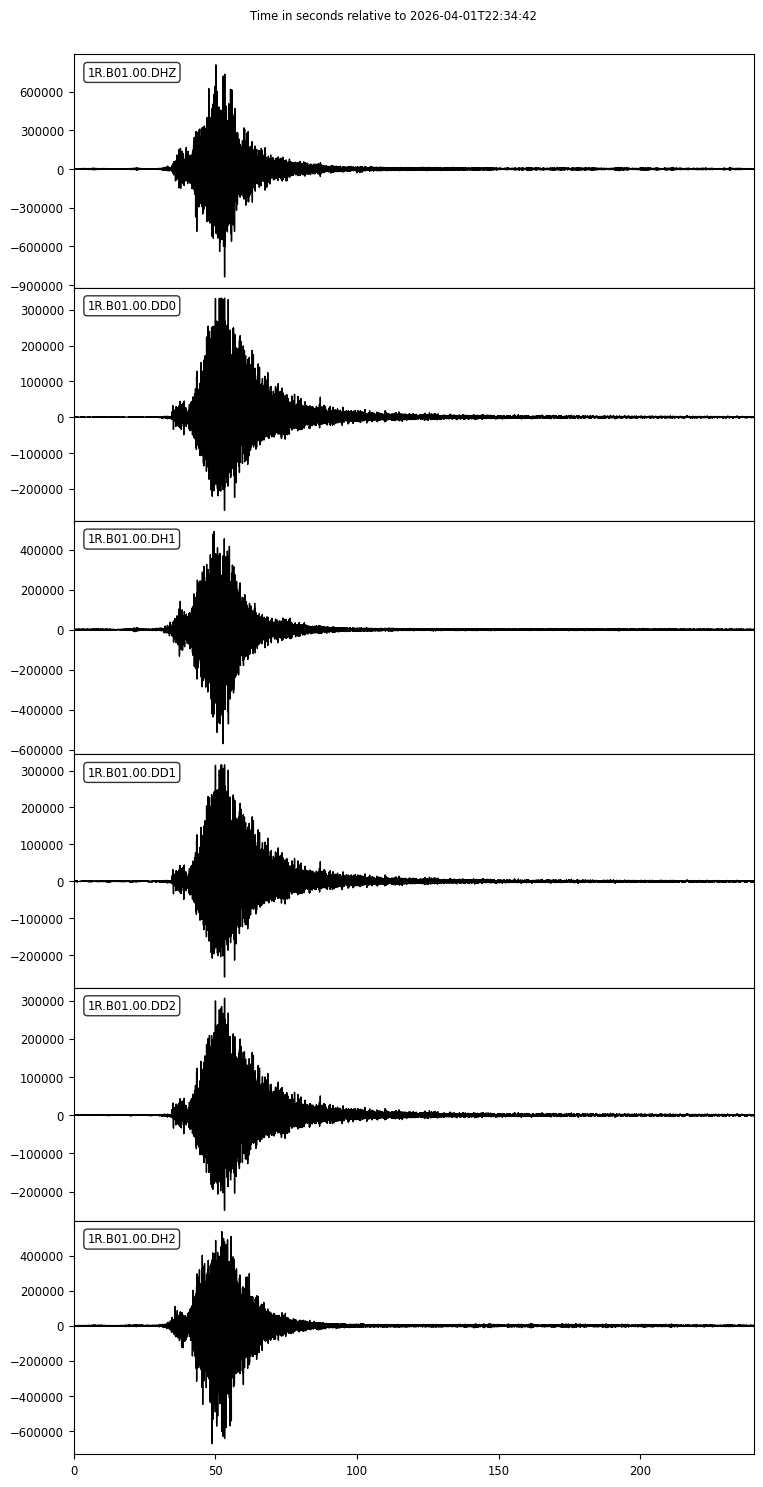

3 Trace(s) in Stream:
1R.B03..HDI   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B03.00.DH1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B03.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


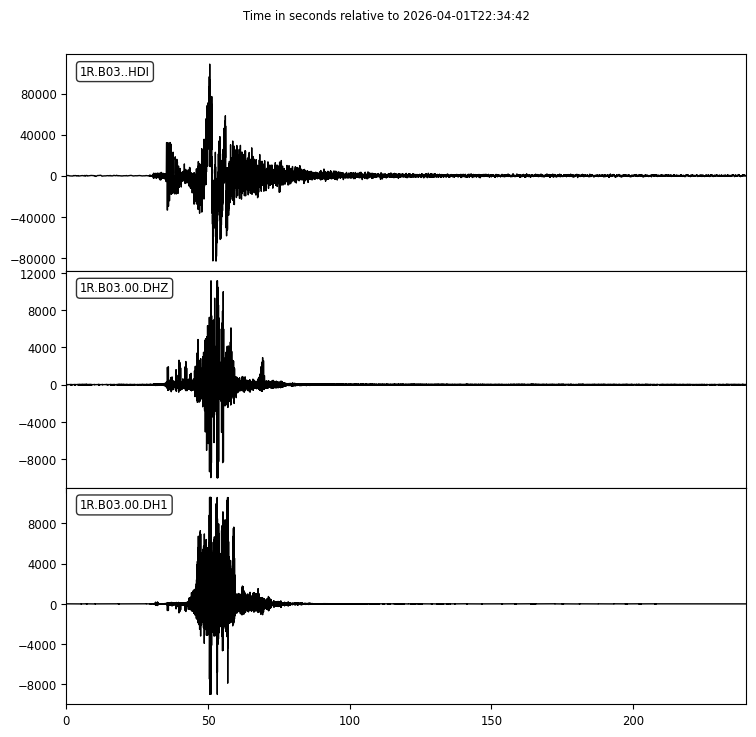

1 Trace(s) in Stream:
1R.B05.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


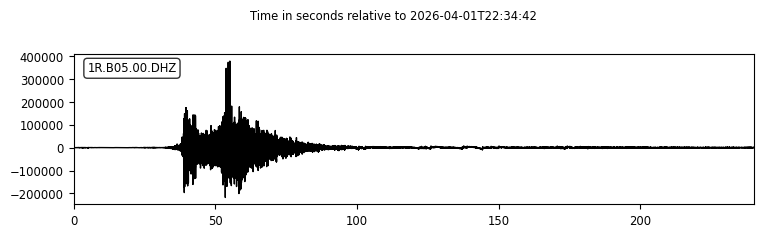

2 Trace(s) in Stream:
1R.B07..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
DG.B07.1L.CHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


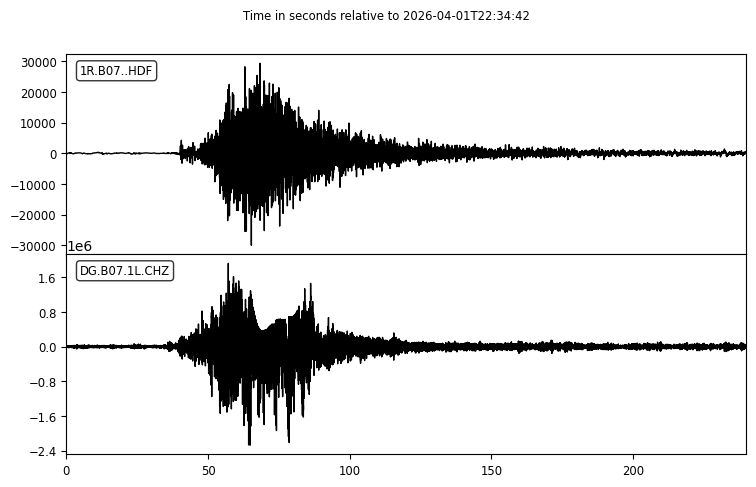

3 Trace(s) in Stream:
DG.B12.1L.CHE | 2026-04-01T22:30:00.534000Z - 2026-04-01T22:45:01.776000Z | 500.0 Hz, 450622 samples
DG.B12.1L.CHN | 2026-04-01T22:30:05.202000Z - 2026-04-01T22:45:04.946000Z | 500.0 Hz, 449873 samples
DG.B12.1L.CHZ | 2026-04-01T22:30:04.532000Z - 2026-04-01T22:44:57.758000Z | 500.0 Hz, 446614 samples


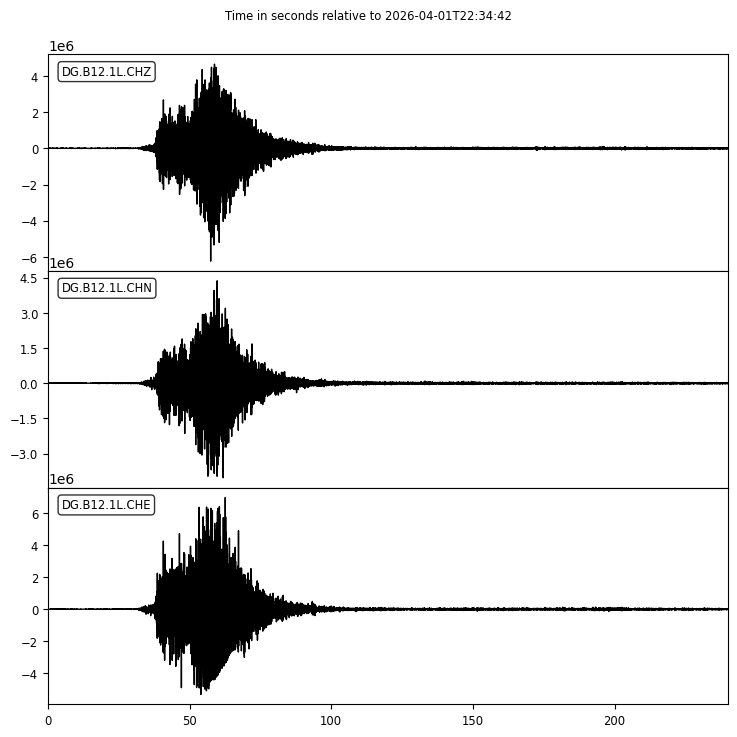

2 Trace(s) in Stream:
1R.B20..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20.10.HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


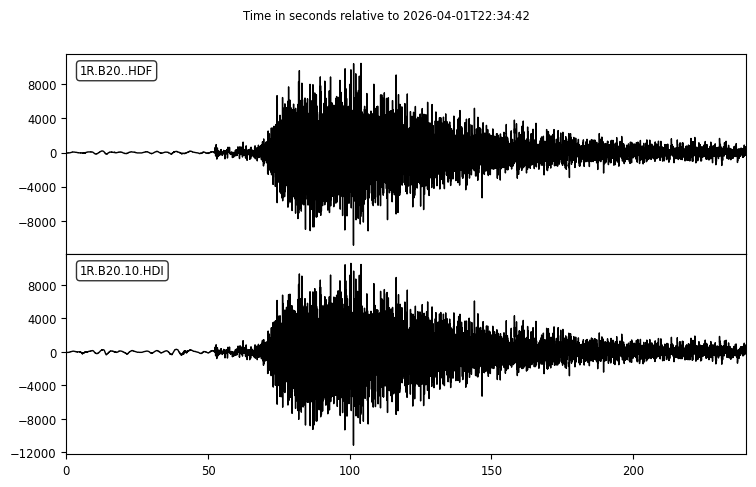

1 Trace(s) in Stream:
1R.B20S..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


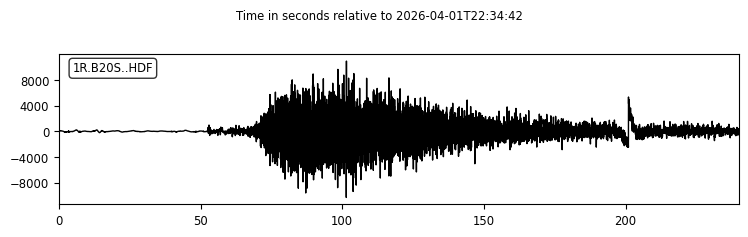

1 Trace(s) in Stream:
1R.B20W..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


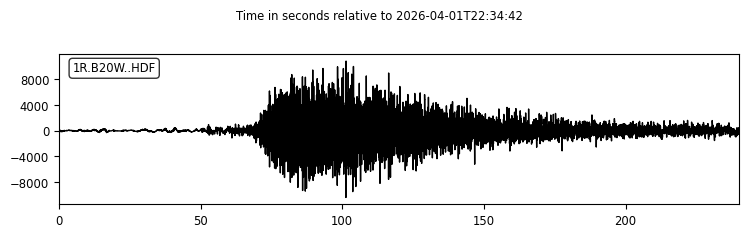

4 Trace(s) in Stream:
1R.B23..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
DG.B23.01.CLE | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
DG.B23.01.CLN | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
DG.B23.01.CLZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


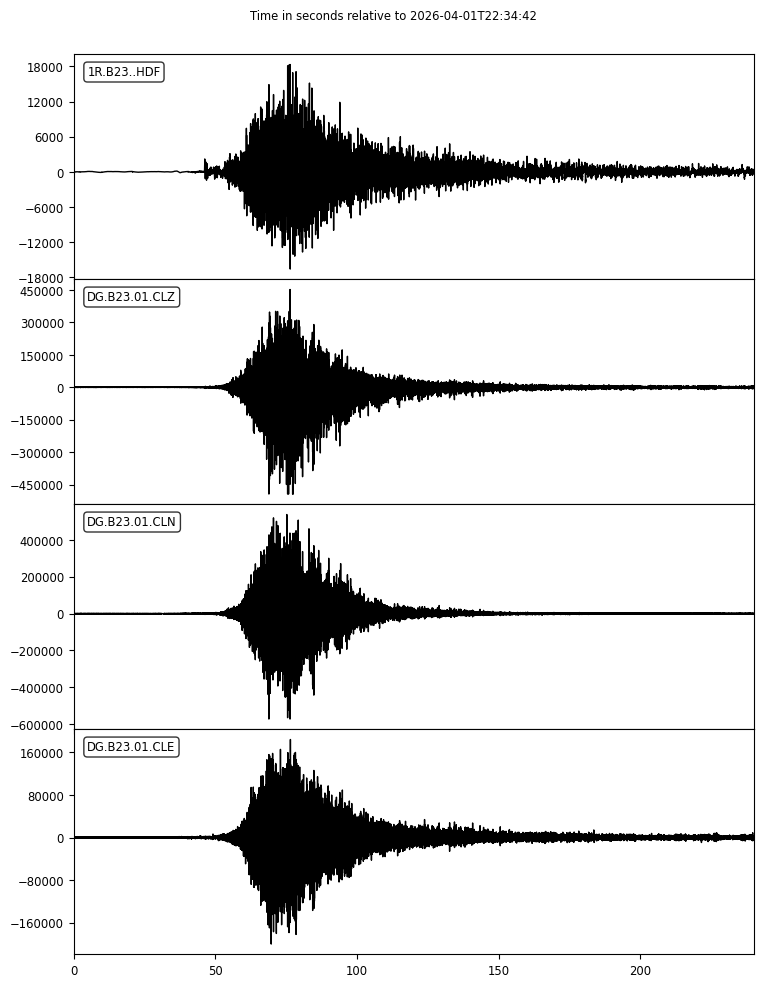

1 Trace(s) in Stream:
1R.B24..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


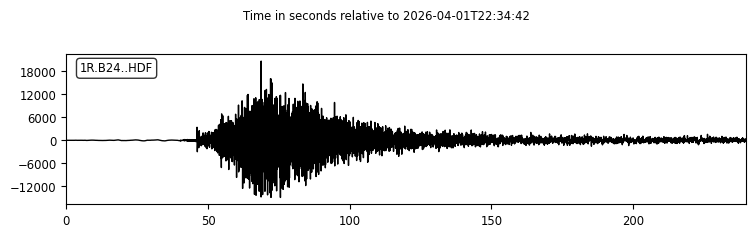

1 Trace(s) in Stream:
1R.B24LT..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


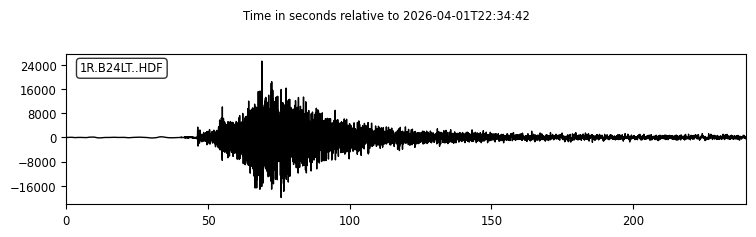

1 Trace(s) in Stream:
1R.B24RE..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples


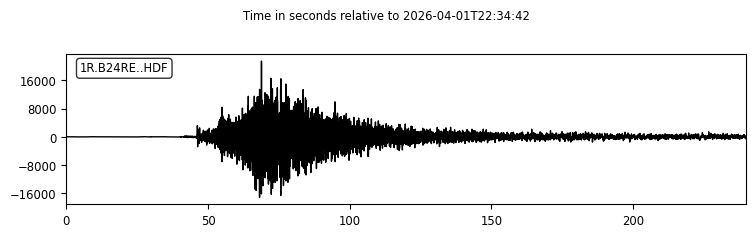

6 Trace(s) in Stream:
1R.B29..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B29..HDI   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B29.00.DD0 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B29.00.DH1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B29.00.DH2 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B29.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


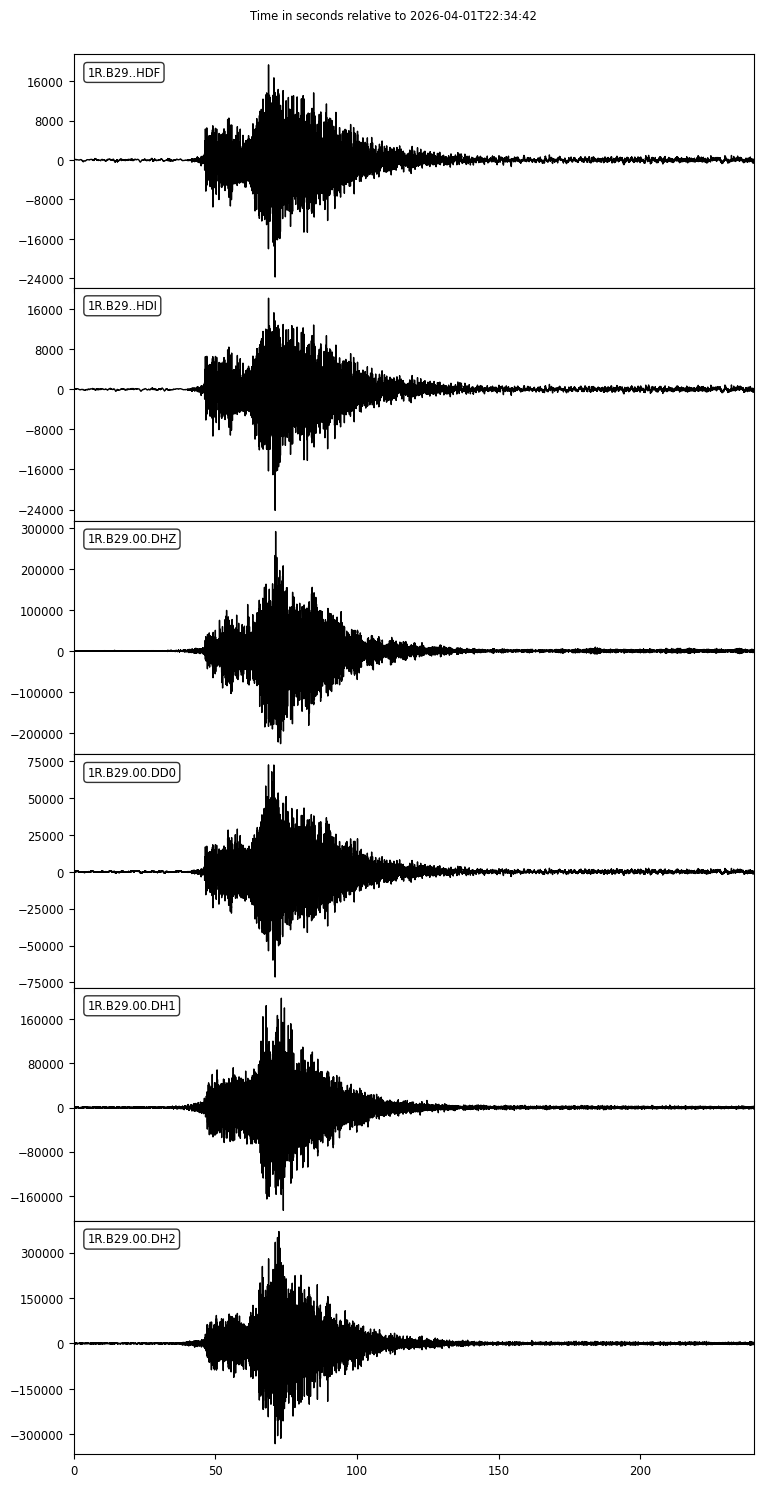

In [7]:
for this_station in stations:
    this_st = stf.select(station=this_station)
    print(this_st)
    this_st.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False);

16 Trace(s) in Stream:
DG.B07.1L.CHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
DG.B12.1L.CHE | 2026-04-01T22:30:00.534000Z - 2026-04-01T22:45:01.776000Z | 500.0 Hz, 450622 samples
DG.B12.1L.CHN | 2026-04-01T22:30:05.202000Z - 2026-04-01T22:45:04.946000Z | 500.0 Hz, 449873 samples
DG.B12.1L.CHZ | 2026-04-01T22:30:04.532000Z - 2026-04-01T22:44:57.758000Z | 500.0 Hz, 446614 samples
DG.B23.01.CLE | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
DG.B23.01.CLN | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
DG.B23.01.CLZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DH1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DH2 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B01.00.DHZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20

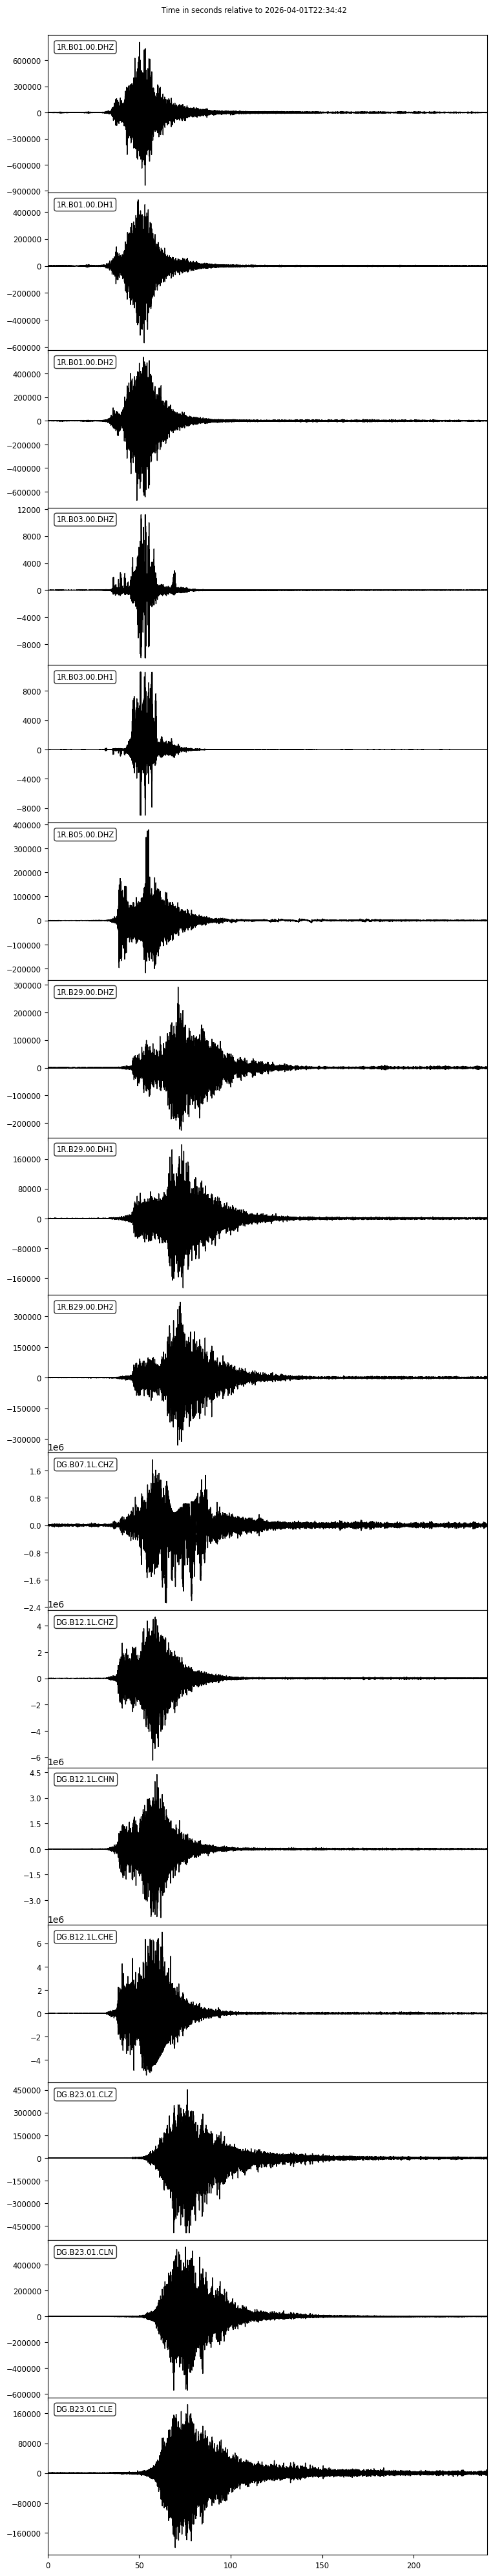

16 Trace(s) in Stream:
1R.B03..HDI   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B07..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20.10.HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20S..HDF  | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20W..HDF  | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B23..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24LT..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24RE..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.00

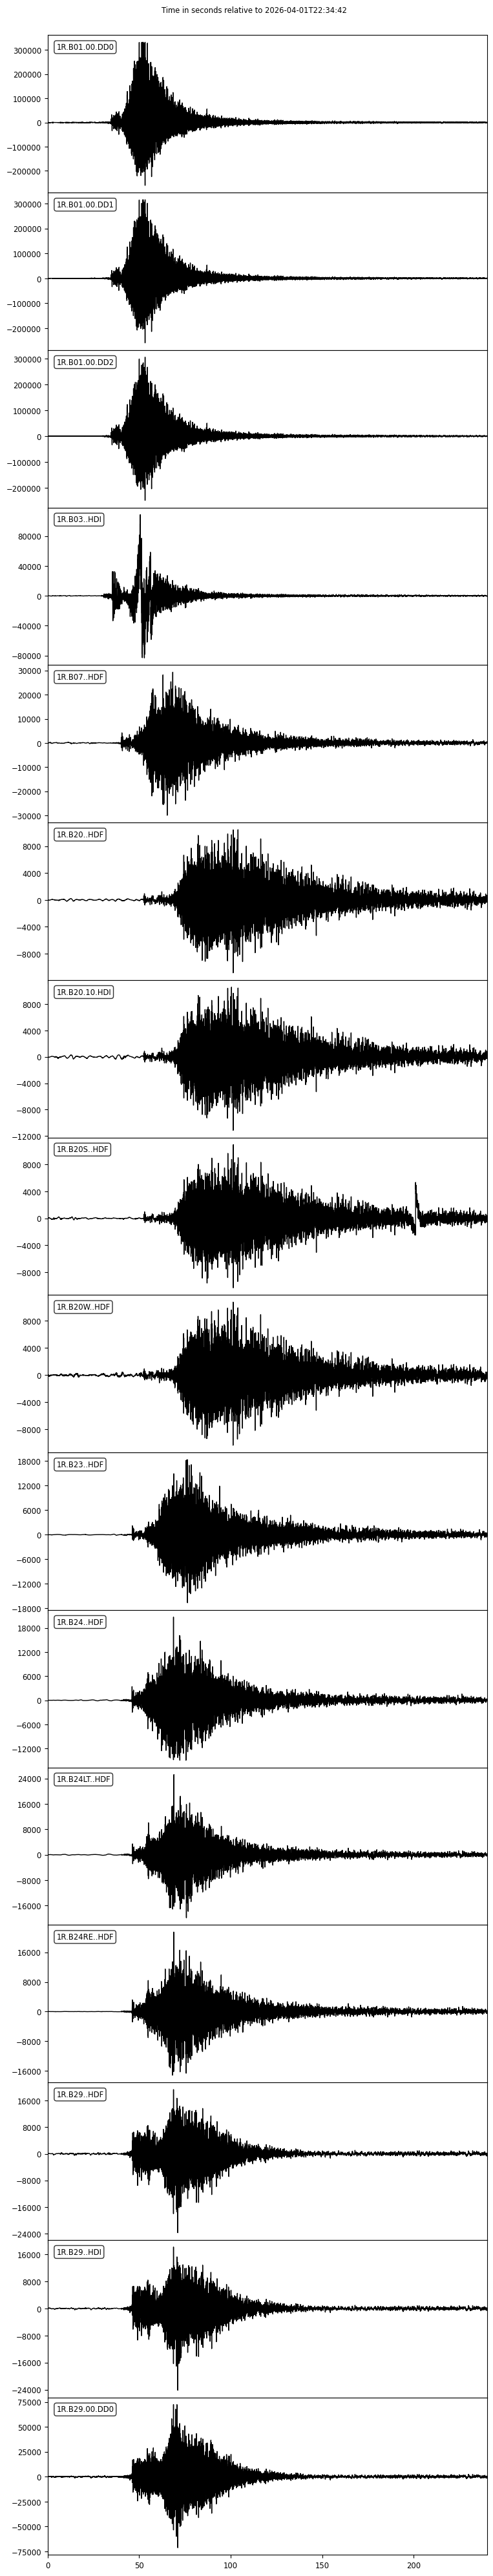

In [8]:
st_seismic = stf.select(channel='*[HL][ZNE012]') 
print(st_seismic)
st_seismic.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False);

st_infrasound = stf.select(channel='*D[F0OI12]') # or '*D[F0I]'
print(st_infrasound)
st_infrasound.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False);

Correct for instrument response

For USF stations, we can use flovopy.

For Guralp stations, do we have something or need to use NRL?

For B23, what do we have?

For Gem we need gemlog.

1R.B01.00.DH1 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B01.00 with channels: ['DH1']


/Volumes/PulwtopHome/Developer/GitHub/flovopy/flovopy/stationmetadata/build.py:82: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL("http://ds.iris.edu/NRL/")


1R.B01.00.DH2 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B01.00 with channels: ['DH2']
1R.B01.00.DHZ 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B01.00 with channels: ['DHZ']
1R.B03.00.DH1 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B03.00 with channels: ['DH1']
1R.B03.00.DHZ 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B03.00 with channels: ['DHZ']
1R.B05.00.DHZ 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B05.00 with channels: ['DHZ']
1R.B29.00.DH1 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory for 1R.B29.00 with channels: ['DH1']
1R.B29.00.DH2 2026-04-01T22:05:12.000000Z 2026-04-01T23:20:12.000000Z
[INFO] NRL2inventory: Building inventory f

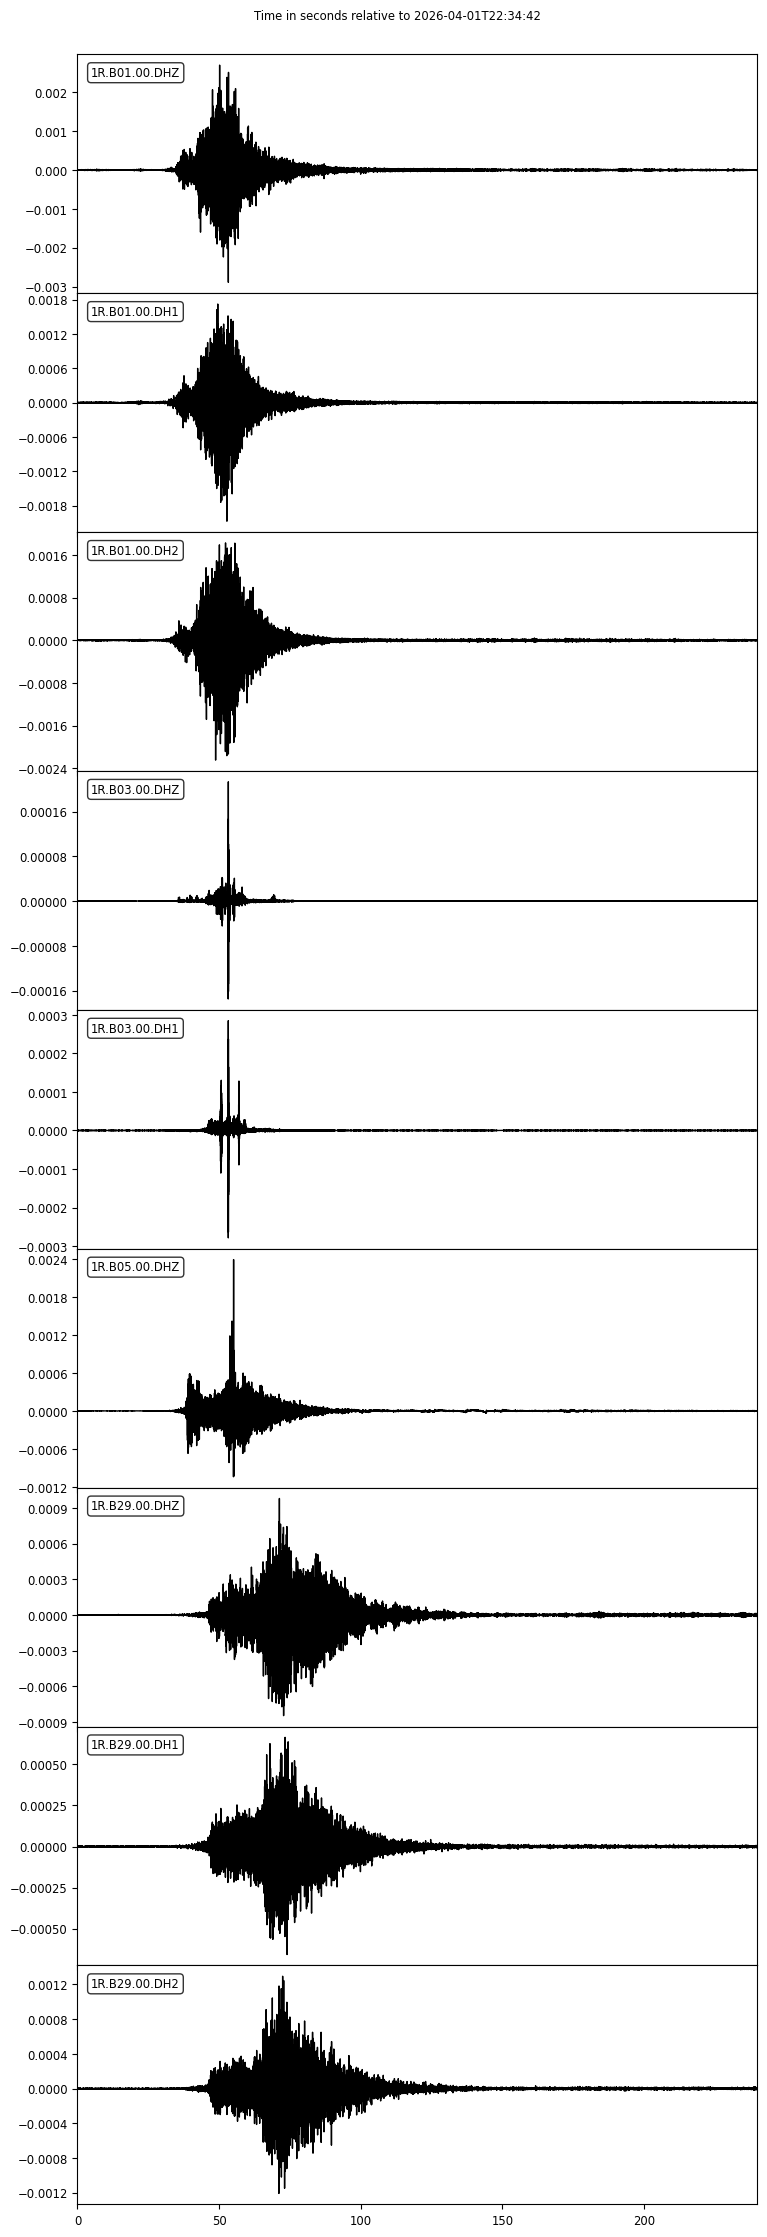

In [9]:
from flovopy.stationmetadata.build import NRL2inventory

st_trillium_corrected = st_seismic.copy().select(channel="DH*")

for tr in st_trillium_corrected:
    print(tr.id, tr.stats.starttime, tr.stats.endtime)

    inv = NRL2inventory(
        nrl_path=None,   # use a local NRL copy
        net=tr.stats.network,
        sta=tr.stats.station,
        loc=tr.stats.location,
        chans=[tr.stats.channel],        # IMPORTANT: list, not string
        datalogger="Centaur",
        sensor="TCP",
        Vpp=40,
        fsamp=tr.stats.sampling_rate,
        lat=0.0,
        lon=0.0,
        elev=0.0,
        depth=0.0,
        sitename="",
        ondate=tr.stats.starttime,
        offdate=tr.stats.endtime,
        sensitivity=None,
        units=None,
    )

    fs = tr.stats.sampling_rate
    nyq = 0.5 * fs
    pre_filt = (0.01, 0.02, 0.94 * nyq, 0.98 * nyq)

    tr.remove_response(
        inventory=inv,
        output="VEL",
        pre_filt=pre_filt,
        zero_mean=True,
        taper=True,
    )

st_trillium_corrected.plot(
    type="relative",
    starttime=starttrim,
    endtime=endtrim,
    show=True,
    equal_scale=False,
);


In [18]:
# Now correct the infraBSU sensors
from flovopy.stationmetadata.build import NRL2inventory

print(st_infrasound)


16 Trace(s) in Stream:
1R.B03..HDI   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B07..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20.10.HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20S..HDF  | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B20W..HDF  | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B23..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24..HDF   | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24LT..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples
1R.B24RE..HDF | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.00

In [ ]:

st_infrabsu_corrected = st_infrasound.copy().select(channel="DD[012F]")  # or "HDF", "BDF", etc., depending on your naming

for tr in st_infrabsu_corrected:
    print(tr.id, tr.stats.starttime, tr.stats.endtime)

    if tr.stats.station == 'B20':
        print(f"Station {tr.stats.station} has channel {tr.stats.channel}, applying special handling for B20 DD0.")
        if tr.stats.channel == 'DDF':
            # chaparral sensor
            inv = NRL2inventory(
                nrl_path=None,   # strongly preferred over remote NRL
                net=tr.stats.network,
                sta=tr.stats.station,
                loc=tr.stats.location,
                chans=[tr.stats.channel],        # IMPORTANT: must be a list
                datalogger="Centaur",
                sensor="Chaparral",
                Vpp=40,
                fsamp=tr.stats.sampling_rate,
                lat=0.0,
                lon=0.0,
                elev=0.0,
                depth=0.0,
                sitename="",
                ondate=tr.stats.starttime,
                offdate=tr.stats.endtime,
                sensitivity=None,
                units="Pa",                      # only used by your fallback path
            )
        elif tr.stats.channel == 'DD0':
            # special case for B20 DD0, which is 40 Vpp since on same Sensor B as the Chaparral DDF
            inv = NRL2inventory(
                nrl_path=None,   # strongly preferred over remote NRL
                net=tr.stats.network,
                sta=tr.stats.station,
                loc=tr.stats.location,
                chans=[tr.stats.channel],        # IMPORTANT: must be a list
                datalogger="Centaur",
                sensor="infrabsu",
                Vpp=40,
                fsamp=tr.stats.sampling_rate,
                lat=0.0,
                lon=0.0,
                elev=0.0,
                depth=0.0,
                sitename="",
                ondate=tr.stats.starttime,
                offdate=tr.stats.endtime,
                sensitivity=None,
                units="Pa",                      # only used by your fallback path
            )
    else:
        inv = NRL2inventory(
            nrl_path=None,   # strongly preferred over remote NRL
            net=tr.stats.network,
            sta=tr.stats.station,
            loc=tr.stats.location,
            chans=[tr.stats.channel],        # IMPORTANT: must be a list
            datalogger="Centaur",
            sensor="infrabsu",
            Vpp=1,
            fsamp=tr.stats.sampling_rate,
            lat=0.0,
            lon=0.0,
            elev=0.0,
            depth=0.0,
            sitename="",
            ondate=tr.stats.starttime,
            offdate=tr.stats.endtime,
            sensitivity=None,
            units="Pa",                      # only used by your fallback path
        )

    fs = tr.stats.sampling_rate
    nyq = 0.5 * fs

    # Example pre-filter; adjust to your actual infrasound band of interest
    pre_filt = (0.001, 0.005, 0.94 * nyq, 0.98 * nyq)

    tr.remove_response(
        inventory=inv,
        output="DEF",                    # safest for pressure/infrasound
        pre_filt=pre_filt,
        zero_mean=True,
        taper=True,
    )


st_infrabsu_corrected.plot(type="relative", show=True, equal_scale=False, starttime=starttrim, endtime=endtrim);

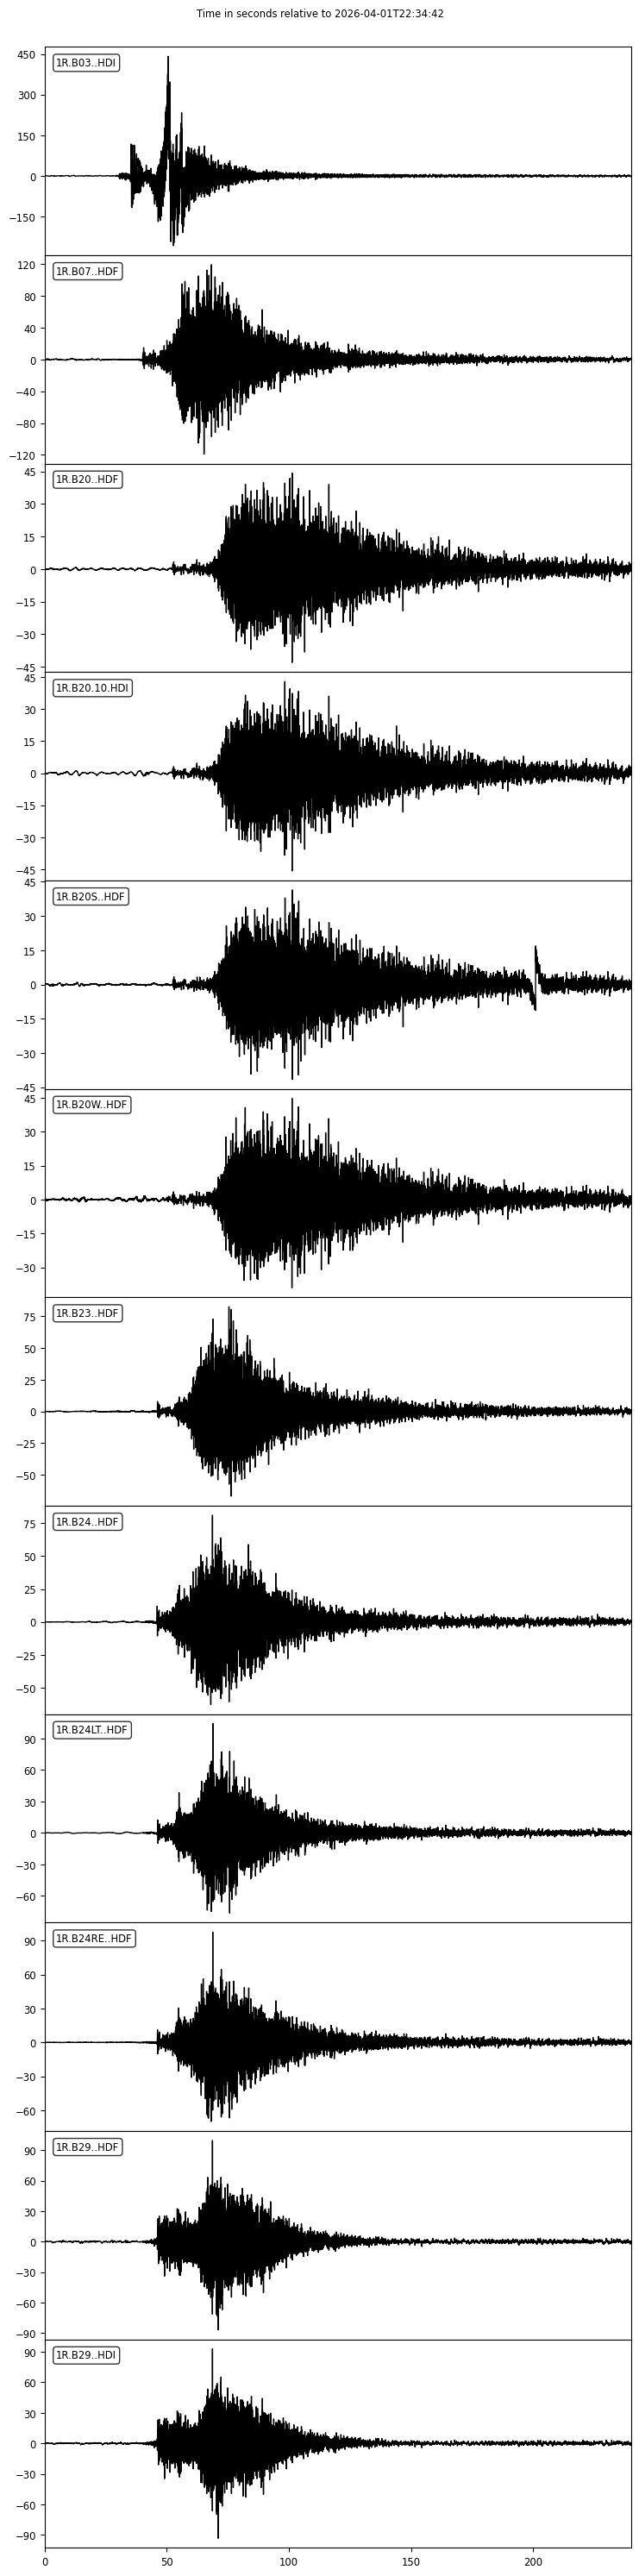

In [11]:

import gemlog
st_gem = st_infrasound.copy().select(channel='*D[FOI]')
st_gem_corrected = gemlog.deconvolve_gem_response(st_gem, gain='high') 
st_gem_corrected.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False);

25 Trace(s) in Stream:

1R.B01.00.DH1 | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
...
(23 other traces)
...
1R.B29..HDI | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 100.0 Hz, 450001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


/opt/anaconda3/envs/flovopy_pygmt/lib/python3.12/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/flovopy_pygmt/lib/python3.12/site-packages/obspy/io/mseed/core.py:1087: UserWarning: File will be written with more than one different record lengths.
This might have a negative influence on the compatibility with other programs.
  warnings.warn(msg % 'record lengths')


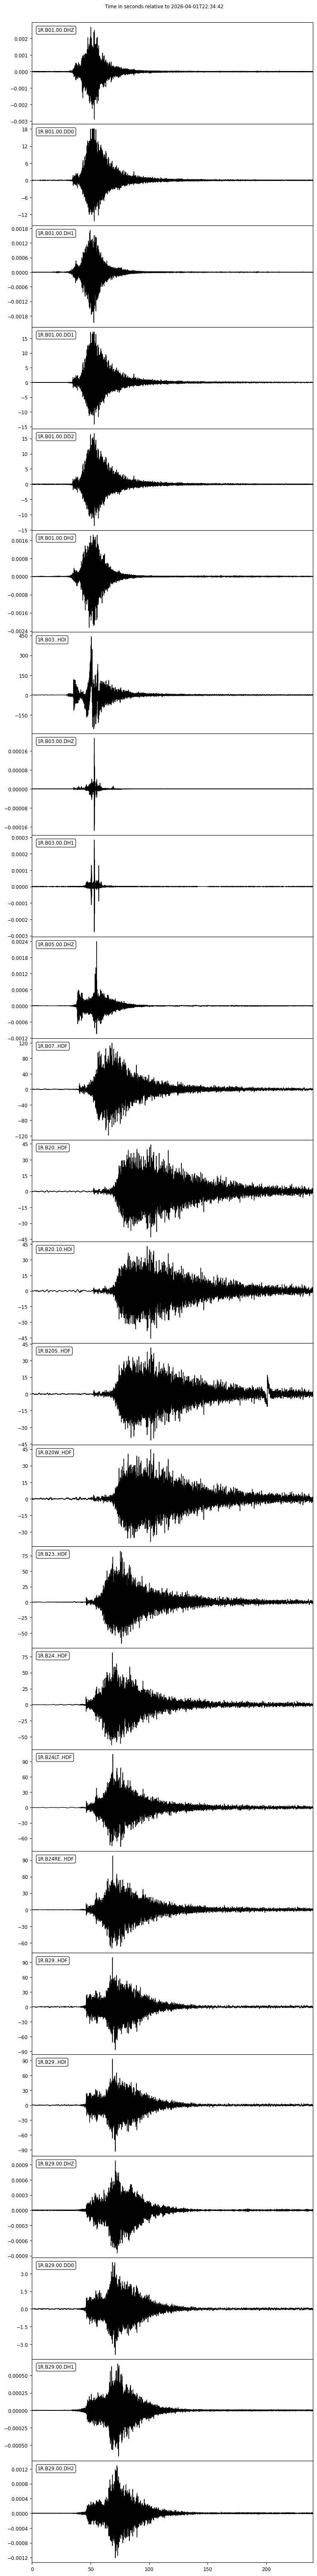

In [12]:
master_stream = Stream()
for st in [st_trillium_corrected, st_infrabsu_corrected, st_gem_corrected]:
    master_stream += st
print(master_stream)
master_stream.write(MSEED_PATH / 'master_stream_corrected.mseed', format='MSEED')
master_stream.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False);

In [13]:
from obspy import read, Stream
if not 'master_stream' in locals():
    master_stream = read(str(MSEED_PATH / 'master_stream_corrected.mseed'))

In [14]:
seismic_subset = Stream(traces=[master_stream.select(station='B01', channel='DHZ')[0],   master_stream.select(station='B29', channel='DHZ')[0]]).trim(starttime=starttrim, endtime=endtrim)
infrasound_subset = Stream(traces=[master_stream.select(station='B01', channel='DD0')[0],   master_stream.select(station='B29', channel='DD0')[0]]).trim(starttime=starttrim, endtime=endtrim)
seismic_subset.plot(equal_scale=True, outfile=MSEED_PATH / 'near_far_seismic_subset.pdf');
infrasound_subset.plot(equal_scale=True, outfile=MSEED_PATH / 'near_far_infrasound_subset.pdf');


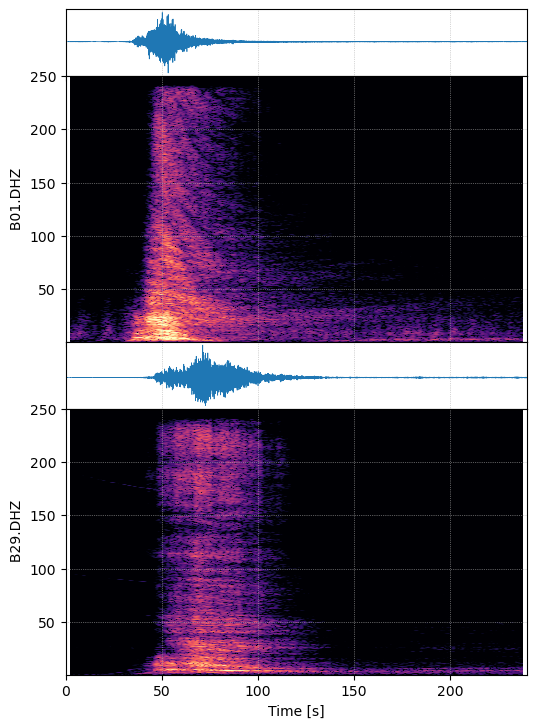

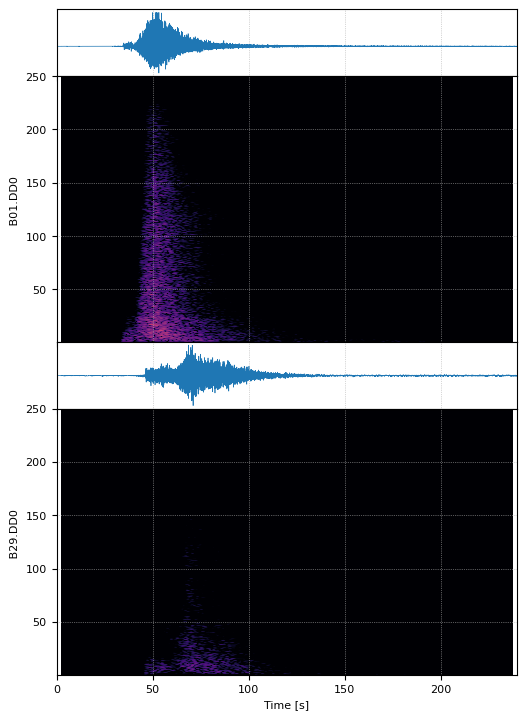

In [15]:

from flovopy.processing.spectrograms import icewebSpectrogram
iwobj = icewebSpectrogram(seismic_subset)
iwobj.precompute()
iwobj.plot(dbscale=True, equal_scale=True, fmax=250.0, clim=[1e-7, 1e-4], cmap='magma', add_colorbar=False, outfile=MSEED_PATH / 'near_far_seismic_spectrogram.png');

iwobji = icewebSpectrogram(infrasound_subset)
iwobji.precompute()
iwobji.plot(dbscale=True, equal_scale=True, fmax=250.0, clim=[2e-2, 2e1], cmap='magma', add_colorbar=False, outfile=MSEED_PATH / 'near_far_infrasound_spectrogram.png');


In [16]:
import numpy as np
import pandas as pd

master_stream_infrasound = master_stream.copy().select(channel='*D[FOI012]')
master_stream_seismic = master_stream.copy().select(channel='*[HL][ZNE012]')

for index, this_stream in enumerate([master_stream_infrasound, master_stream_seismic]):
    if index == 0:
        trace_type = 'Infrasound'
        digits = 1
    else:
        trace_type = 'Seismic'
        digits = 6
    print(f"Processing {trace_type} traces:")
    peak_amplitudes = {}
    for tr in this_stream:
        tr.detrend(type='demean')
        data = np.abs(tr.data)
        peak_amplitudes[tr.id] = data.max()
    peak_amplitudes = {k: v for k, v in sorted(peak_amplitudes.items(), key=lambda item: item[1], reverse=True)}
    print('Peak amplitudes for each trace (sorted):')

    df = pd.DataFrame(list(peak_amplitudes.items()), columns=['Trace ID', 'Peak Amplitude'])
    df.to_csv(MSEED_PATH.parent / f'peak_{trace_type.lower()}_amplitudes.csv', index=False)
    df['Peak Amplitude'] = df['Peak Amplitude'].round(digits)
    display(df)
    

Processing Infrasound traces:
Peak amplitudes for each trace (sorted):


,Trace ID,Peak Amplitude
0,1R.B03..HDI,1601.4
1,1R.B07..HDF,119.5
2,1R.B24LT..HDF,104.3
3,1R.B29..HDF,99.6
4,1R.B24RE..HDF,97.6
5,1R.B29..HDI,93.4
6,1R.B23..HDF,82.5
7,1R.B24..HDF,81.0
8,1R.B20.10.HDI,45.8
9,1R.B20W..HDF,44.7


Processing Seismic traces:
Peak amplitudes for each trace (sorted):


,Trace ID,Peak Amplitude
0,1R.B01.00.DHZ,0.002891
1,1R.B05.00.DHZ,0.002394
2,1R.B01.00.DH2,0.002244
3,1R.B01.00.DH1,0.002074
4,1R.B29.00.DH2,0.001294
5,1R.B29.00.DHZ,0.000979
6,1R.B29.00.DH1,0.000665
7,1R.B03.00.DH1,0.000285
8,1R.B03.00.DHZ,0.000213


In [ ]:
import numpy as np
from obspy import read
from scipy.io.wavfile import write as wavwrite
from scipy.signal import resample

def trace_to_audio(
    tr,
    speedup=100,
    output_wav="output.wav",
    audio_rate=44100,
    normalize=True,
    detrend=True,
    taper=True,
    bandpass=None,
):
    """
    Convert an ObsPy Trace to a WAV audio file by speeding it up.

    Parameters
    ----------
    tr : obspy.Trace
        Input seismic trace.
    speedup : float
        Factor by which to speed up playback.
    output_wav : str
        Output WAV filename.
    audio_rate : int
        Desired WAV sample rate in Hz.
    normalize : bool
        If True, scale data to int16 range.
    detrend : bool
        If True, remove mean and linear trend.
    taper : bool
        If True, apply a short taper.
    bandpass : tuple or None
        Optional (fmin, fmax) in Hz for pre-filtering the seismic data.
    """
    tr = tr.copy()

    if detrend:
        tr.detrend("linear")

    if taper:
        tr.taper(max_percentage=0.02)

    if bandpass is not None:
        fmin, fmax = bandpass
        tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    data = tr.data.astype(np.float64)

    # Remove NaNs/infs if present
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    # Effective sampling rate after speeding up
    effective_rate = tr.stats.sampling_rate * speedup

    # Resample to desired audio rate if needed
    if abs(effective_rate - audio_rate) / audio_rate > 0.01:
        n_out = int(round(len(data) * audio_rate / effective_rate))
        if n_out <= 0:
            raise ValueError("Output sample count is invalid.")
        data = resample(data, n_out)

    if normalize:
        peak = np.max(np.abs(data))
        if peak > 0:
            data = data / peak
        data_int16 = np.int16(data * 32767)
    else:
        data_int16 = np.int16(np.clip(data, -32768, 32767))

    wavwrite(output_wav, audio_rate, data_int16)
    return output_wav


Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DH2_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B03.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B03.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B05.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DH2_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD0_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD2_audio.wav
Crea

In [19]:

for tr in master_stream.copy().trim(starttime=starttrim, endtime=endtrim):
    output_wav = MSEED_PATH.parent / f'{tr.id}_audio.wav'
    trace_to_audio(tr, speedup=60, output_wav=str(output_wav), audio_rate=44100, normalize=True, detrend=True, taper=True)#, bandpass=(0.1, 240))
    print(f'Created audio file: {output_wav}')

Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DH2_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B03.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B03.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B05.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DH1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DH2_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B29.00.DHZ_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD0_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD1_audio.wav
Created audio file: /Users/GlennThompson/Dropbox/KSC_paper/1R.B01.00.DD2_audio.wav
Crea